In [1]:
import numpy as np
from algorithims.learning.agregator import load_pickle
from algorithims.learning.utils import aggregate_metrics

In [2]:
!pwd

/home/ubuntu/uai_code/exp/exp_2


In [3]:
import glob
basepath = "./results"

In [4]:
algos = ["U", "E_NS", "E_PSM", "EE_PSM", "U_PSM"]
N = [2, 3, 5, 10, 20]

In [5]:
metrics_final= {}
metrics_all = {}
Delta_min = 0.2
delta = 0.1
for algo in algos:
    metrics_final[algo] = {"sample_complexity": [],
                           "sample_complexity_std": [],
                           "correctness": [],
                           "N" : []}
    metrics_all[algo] = {}
    for n in N:
        metrics_all[algo][n] = {}
        try:
            paths = glob.glob(basepath +f"/final_{algo}_N_{n}_D_{Delta_min}_delta_{delta}.pkl", recursive=True)
            path = [p for p in paths if not p.endswith("/")][0]
            metrics = load_pickle(path)
            # break
            metrics_agg = aggregate_metrics(metrics)
            
            sample_complexity = np.mean(metrics_agg[0])
            sc_std = np.std(metrics_agg[0])
            cor = np.mean(metrics_agg[1])
            metrics_final[algo]["sample_complexity"] += [sample_complexity]
            metrics_final[algo]["sample_complexity_std"] += [sc_std]
            metrics_final[algo]["correctness"] += [cor]
            metrics_final[algo]["N"] += [n]
            metrics_all[algo][n] = metrics_agg
        except:
            metrics_final[algo]["sample_complexity"] += [0]
            metrics_final[algo]["sample_complexity_std"] += [0]
            metrics_final[algo]["correctness"] += [0]
            metrics_final[algo]["N"] += [n]
            metrics_all[algo][n] = metrics_agg

NameError: name 'metrics_agg' is not defined

In [27]:
import pandas as pd
pd.DataFrame(metrics_final)

,uniform,elim_ns,uniform_psm,psm,psm_sr3
sample_complexity,"[3347.74, 9338.67, 21964.15, 57951.0, 144058.2]","[3441.32, 7060.2, 14873.81, 32383.48, 65444.29]","[1886.12, 4426.65, 9731.45, 27963.1, 69902.0]","[1847.0, 4226.01, 8180.82, 21820.22, 49642.52]","[1953.24, 4123.49, 8329.15, 20686.04, 0]"
sample_complexity_std,"[2248.6484946296073, 4170.936151645096, 4549.6...","[2406.050526817756, 2732.8806230788787, 2942.7...","[1635.0044604220504, 3685.640238479605, 6999.2...","[1478.00629227348, 3169.4720900963935, 4915.32...","[1786.4039135649027, 3156.0336262308742, 4678...."
correctness,"[1.0, 1.0, 1.0, 1.0, 1.0]","[1.0, 1.0, 1.0, 1.0, 1.0]","[1.0, 1.0, 1.0, 1.0, 1.0]","[1.0, 1.0, 1.0, 1.0, 1.0]","[1.0, 1.0, 1.0, 1.0, 0]"
N,"[2, 3, 5, 10, 20]","[2, 3, 5, 10, 20]","[2, 3, 5, 10, 20]","[2, 3, 5, 10, 20]","[2, 3, 5, 10, 20]"


In [28]:
min_Delta = 0.2
sample_complexity = []
for N in  [2, 3, 5, 10, 20]:
    h = int(np.ceil(8 * np.log(2 * N * N / delta) / (min_Delta ** 2)))
    sample_complexity += [N*h]

In [29]:
etc_dict = {"sample_complexity":sample_complexity,
            "sample_complexity_std":[0,0,0,0,0],
            "N":[2, 3, 5, 10, 20]}

In [30]:
metrics_final["U_Δ"] = etc_dict

In [31]:
data = metrics_final
rename = {
    "U_Δ":  "U-Δ",
    "U": "U",
    "E_NS": "E-NS",
    "U_PSM": "U-PSM",
    "E_PSM": "E-PSM",
    "EE_PSM": "EE-PSM"
}

data_renamed = {
    rename[k]: v
    for k, v in data.items()
}

In [32]:
data = data_renamed

In [33]:
data.keys()

dict_keys(['U', 'E-NS', 'U-PSM', 'E-PSM', 'EE-PSM', 'U-Δ'])

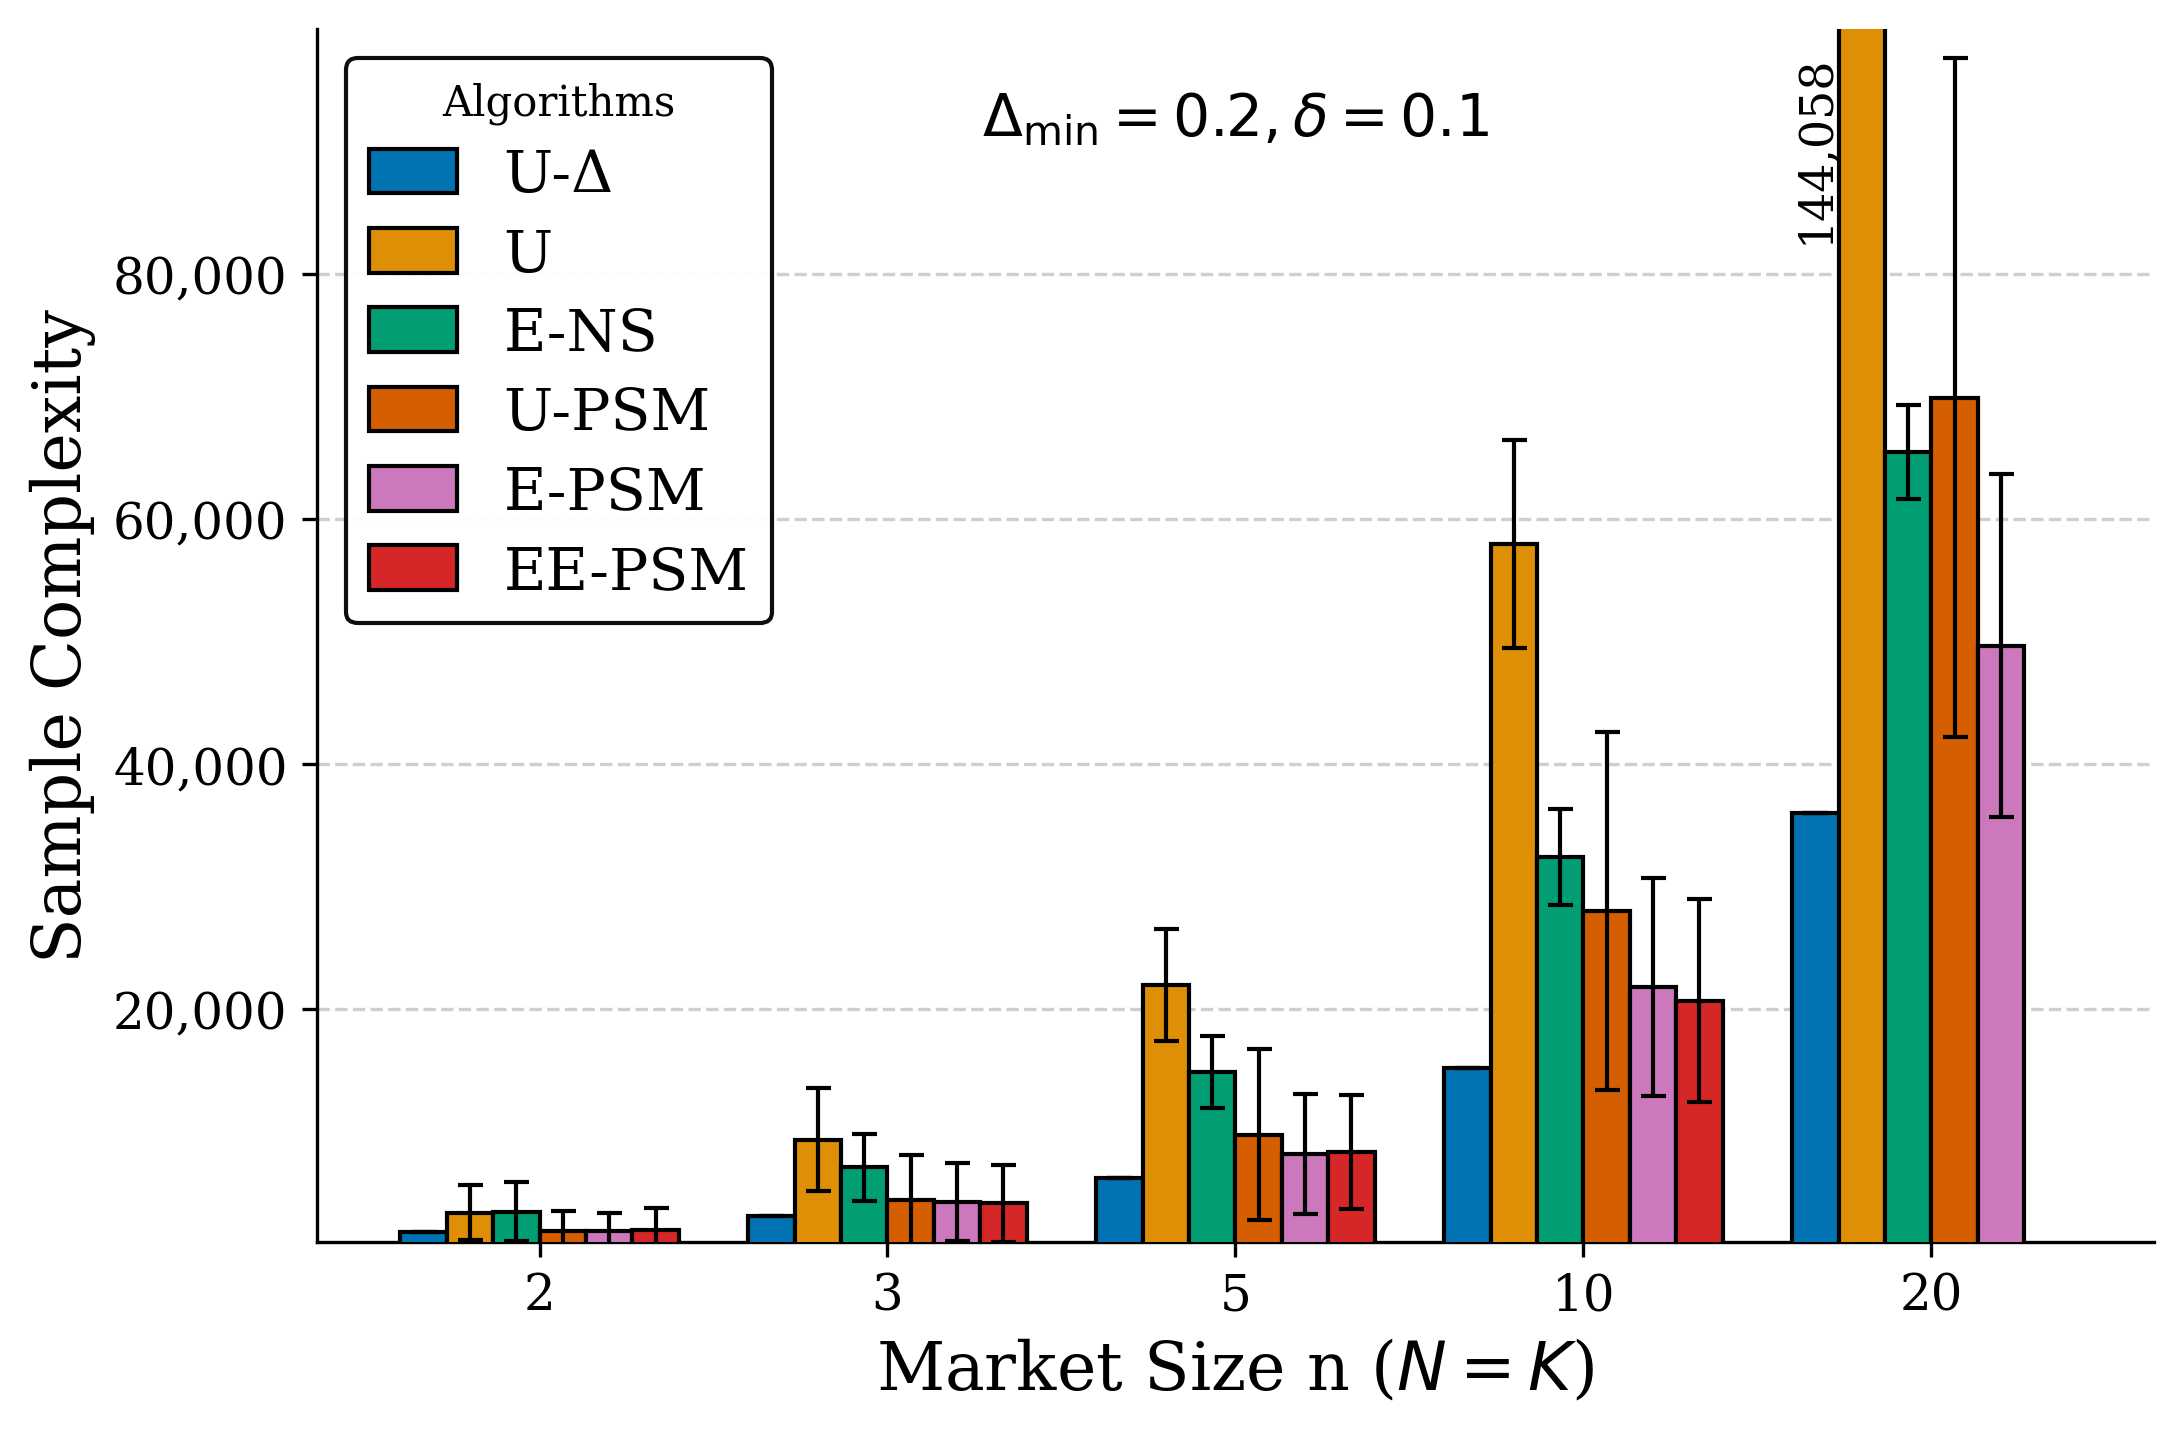

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import StrMethodFormatter

# --- Publication-Ready Formatting ---
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
    "legend.title_fontsize": 11,
    "figure.dpi": 300,
})

# Colorblind-friendly palette with the final bar set to classic Red
colors = ['#0173b2', '#de8f05', '#029e73', '#d55e00', '#cc78bc', '#d62728']
hatches = ['', '', '', '', '', '']

algorithms = list(rename.values())
N_vals = data[algorithms[0]]['N']

num_algos = len(algorithms)
num_N = len(N_vals)

x = np.arange(num_N)
width = 0.8 / num_algos

# Made the figure slightly taller to accommodate the title and error bars comfortably
fig, ax = plt.subplots(figsize=(7.5, 5)) 

for i, algo in enumerate(algorithms):
    y = data[algo]['sample_complexity']
    y_std = data[algo]['sample_complexity_std']  # Extract the standard deviation
    
    ax.bar(
        x + i * width,
        y,
        width,
        yerr=y_std,                                  # Adds the error bars
        capsize=3,                                   # Adds horizontal caps to the error bars
        error_kw={'elinewidth': 1, 'capthick': 1},   # Keeps the error bar lines thin and clean
        label=algo,
        color=colors[i % len(colors)],
        edgecolor='black',
        linewidth=1.0,
        hatch=hatches[i % len(hatches)],
        zorder=3
    )

# Axes & labels
ax.set_xlabel(r"Market Size n ($N=K$)")
ax.set_ylabel("Sample Complexity")

# Add the LaTeX-formatted title
# ax.set_title(r"$\Delta_{\min} = 0.2, \delta = 0.1$", fontsize=14, pad=15)

ax.set_xticks(x + width * (num_algos - 1) / 2)
ax.set_xticklabels(N_vals)

# Format y-axis with commas for large numbers
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Grid styling
ax.grid(axis="y", linestyle="--", alpha=0.6, zorder=0)

# Legend placement
ax.legend(
    title="Algorithms", 
    loc='upper left', 
    fontsize=14,            # Shrinks the text of the algorithm names
    title_fontsize=10,     # Shrinks the "Algorithms" title
    handlelength=1.5,      # Makes the colored boxes slightly narrower
    handleheight=0.8,      # Makes the colored boxes slightly shorter
    labelspacing=0.4,      # Reduces the vertical empty space between items
    borderpad=0.4,         # Reduces the padding around the inside edges of the box
    framealpha=0.95, 
    edgecolor='black'
)
# ax.set_yscale("log")
# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(
    0.5, 0.95, 
    r"$\Delta_{\min} = 0.2, \delta = 0.1$", 
    fontsize=14, 
    ha='center',       # Horizontal alignment
    va='top',          # Vertical alignment
    transform=ax.transAxes, # Uses relative axes coordinates (0 to 1)
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=3), zorder=5
)
x = 4#4.13
Y_MAX = 100000
algo = "U"
val = data[algo]['sample_complexity'][-1]
ax.text(
                x,         # X-coordinate (perfectly centered on the bar)
                Y_MAX * 0.98,             # Y-coordinate (just slightly below the top edge)
                f"{val:,.0f}",            # Formats the number with commas (e.g., 144,058)
                ha='center',              # Horizontally center the text
                va='top',                 # Vertically align to the top
                fontsize=11,
                rotation=90,              # Rotate 90 degrees so it fits inside the narrow bar
                color='black',
                zorder=10,                # Ensure it draws on top of everything
                
            )
ax.set_ylim(bottom=1000, top=99999)
plt.tight_layout()


# Save as PDF for LaTeX
plt.savefig("exp2.png", dpi=300, bbox_inches='tight')
plt.show()